In [1]:
# Importing Necessary Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load dataset
df = pd.read_csv("titanic_data.csv")

In [3]:
# Understand Data
df.head()
df.tail()
df.info()
df.describe(include='all')
df.shape
df.isnull()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [4]:
# Removing Duplicates
df = df.drop_duplicates()
print(df)


     PassengerId  Survived  Pclass  \
0            892         0       3   
1            893         1       3   
2            894         0       2   
3            895         0       3   
4            896         1       3   
..           ...       ...     ...   
413         1305         0       3   
414         1306         1       1   
415         1307         0       3   
416         1308         0       3   
417         1309         0       3   

                                             Name     Sex   Age  SibSp  Parch  \
0                                Kelly, Mr. James    male  34.5      0      0   
1                Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                       Myles, Mr. Thomas Francis    male  62.0      0      0   
3                                Wirz, Mr. Albert    male  27.0      0      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   
..                                            ...     ...

In [7]:
#handling missing values
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Fare']=df['Fare'].fillna(df['Fare'].mean())
df['Cabin']=df['Cabin'].fillna(df['Cabin'].mode()[0])
cab=df['Cabin'].tolist()
print(cab)
single_list=[item for element in cab for item in element.split()]
print(single_list)
df['Cabin']=np.random.choice(single_list,size=len(df))
print(df)


['B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B45', 'B57 B59 B63 B66', 'E31', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B36', 'B57 B59 B63 B66', 'A21', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'C78', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'D34', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'D19', 'B57 B59 B63 B66', 'A9', 'B57 B59 B63 B66', 'D15', 'B57 B59 B63 B66', 'C31', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'C23 C25 C27', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'B57 B59 B63 B66', 'F G63', 'B57 B59 B63 B66', 'B61', 'B57 B

NameError: name 'np' is not defined

In [8]:
# Verify No Missing values Remain
df.isnull().sum()


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [9]:
#Encoding categorical variables
df['Sex']=df['Sex'].map({'male':0,'female':1})


Survived
0    266
1    152
Name: count, dtype: int64


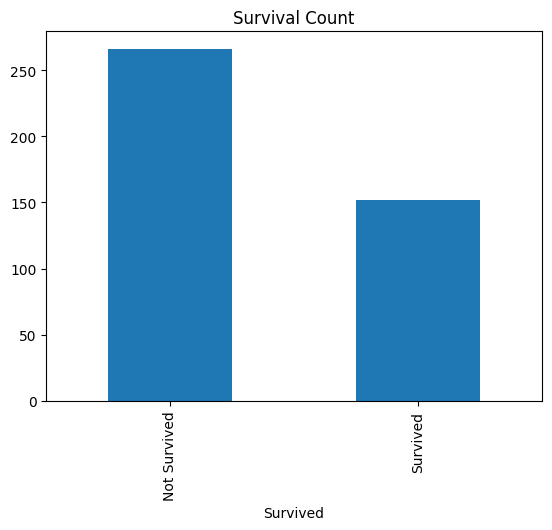

In [10]:
# -------------------- Univariate Analysis --------------------

# Survival Count
print(df['Survived'].value_counts())
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.show()

Sex
0    266
1    152
Name: count, dtype: int64


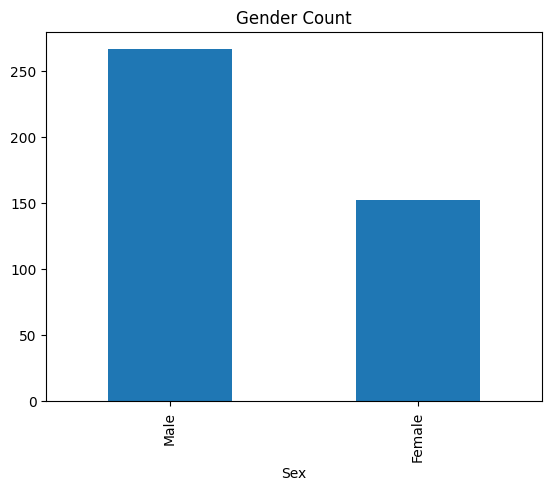

In [11]:
# Gender Count
print(df['Sex'].value_counts())
df['Sex'].value_counts().plot(kind='bar')
plt.title("Gender Count")
plt.xticks([0, 1], ["Male", "Female"])
plt.show()


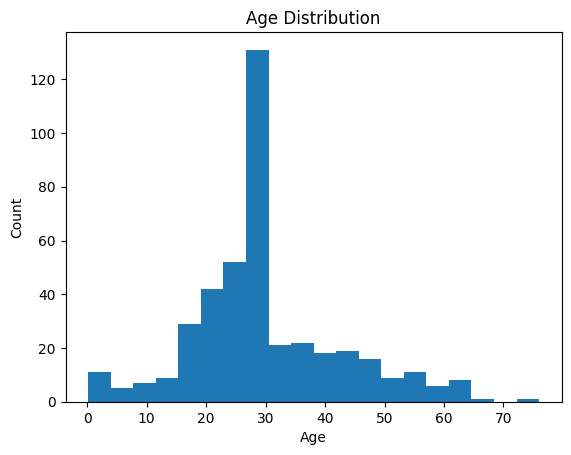

In [12]:
# Histogram (Age)
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


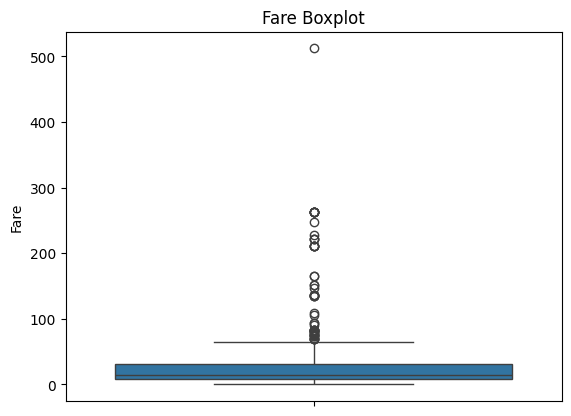

In [13]:
# Boxplot (Fare)
sns.boxplot(y=df['Fare'])
plt.title("Fare Boxplot")
plt.show()


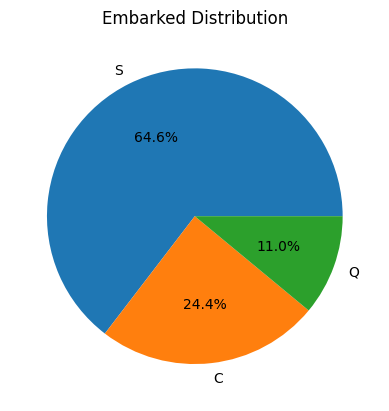

In [14]:
# Pie Chart (Embarked)
df['Embarked'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Embarked Distribution")
plt.ylabel('')
plt.show()

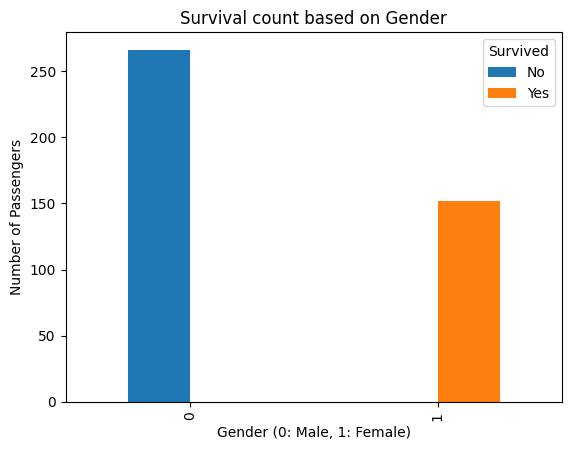

In [15]:
# -------------------- Bivariate Analysis --------------------

# Crosstab (Gender vs Survival)
ct = pd.crosstab(df['Sex'], df['Survived'])
ct.plot(kind='bar')
plt.title("Survival count based on Gender")
plt.xlabel("Gender (0: Male, 1: Female)")
plt.ylabel("Number of Passengers")
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

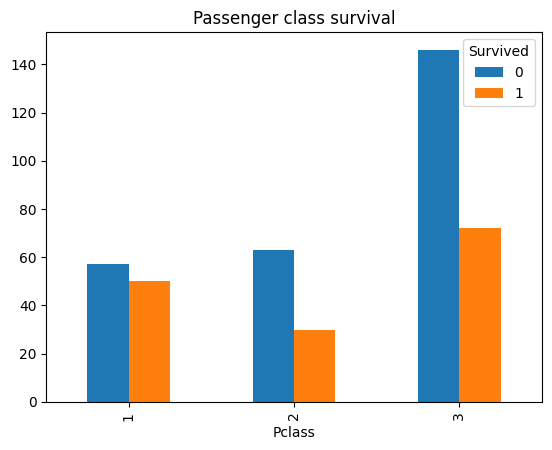

In [16]:
# Crosstab (Pclass vs Survival)
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')
plt.title("Passenger class survival")
plt.show()

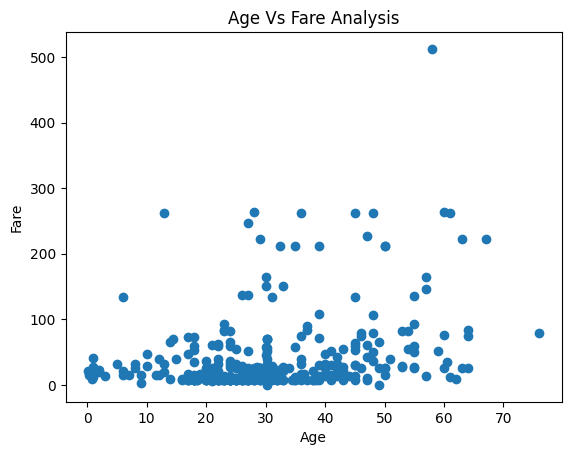

In [17]:
# Scatter Plot (Age vs Fare)
plt.scatter(df['Age'], df['Fare'])
plt.title("Age Vs Fare Analysis")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


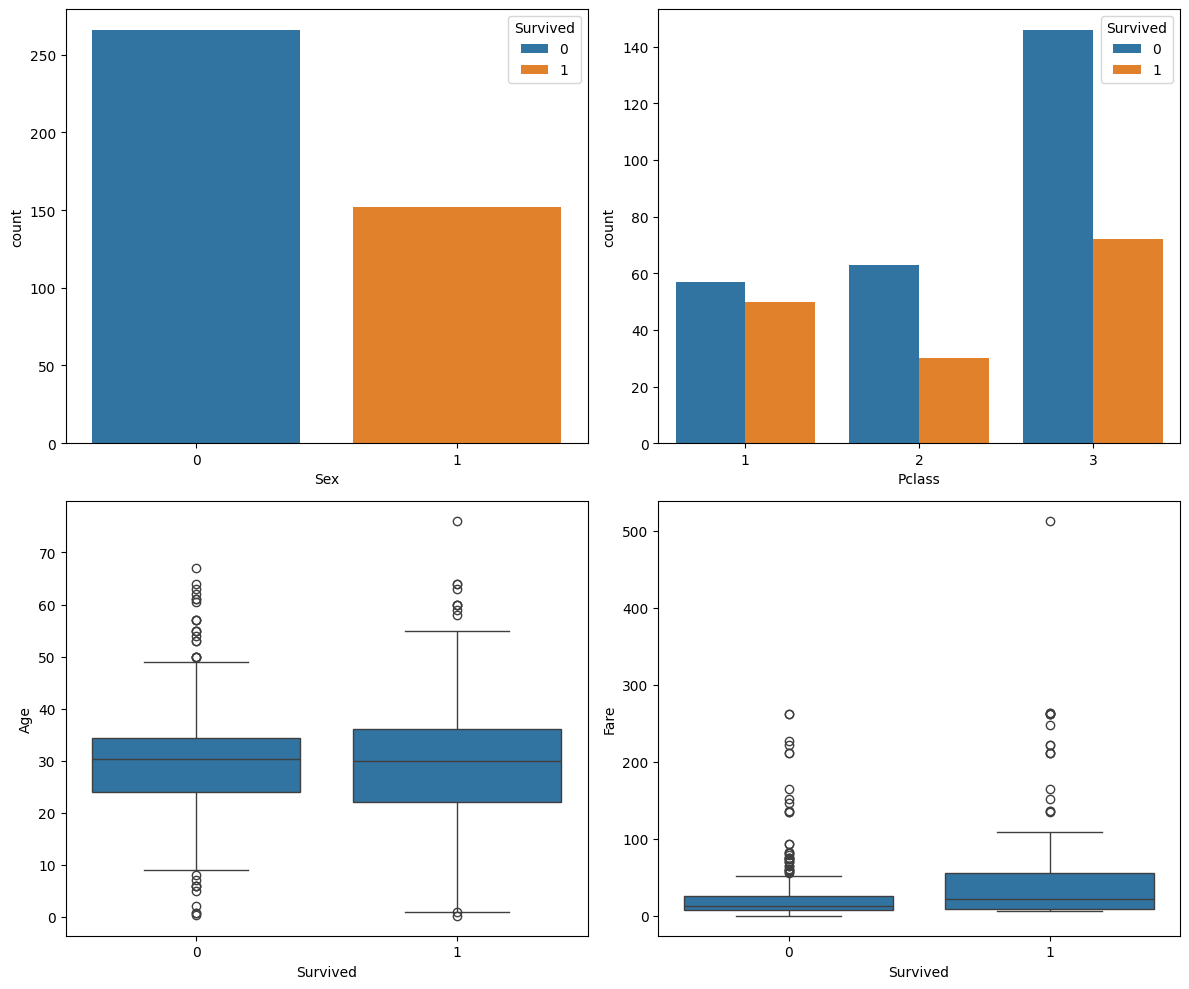

In [19]:
# -------------------- Subplots --------------------

plt.figure(figsize=(12, 10))

# Survival vs Gender
plt.subplot(2, 2, 1)
sns.countplot(x='Sex', hue='Survived', data=df)

# Survival vs Class
plt.subplot(2, 2, 2)
sns.countplot(x='Pclass', hue='Survived', data=df)

# Age vs Survival
plt.subplot(2, 2, 3)
sns.boxplot(x='Survived', y='Age', data=df)

# Fare vs Survival
plt.subplot(2, 2, 4)
sns.boxplot(x='Survived', y='Fare', data=df)

plt.tight_layout()
plt.show()

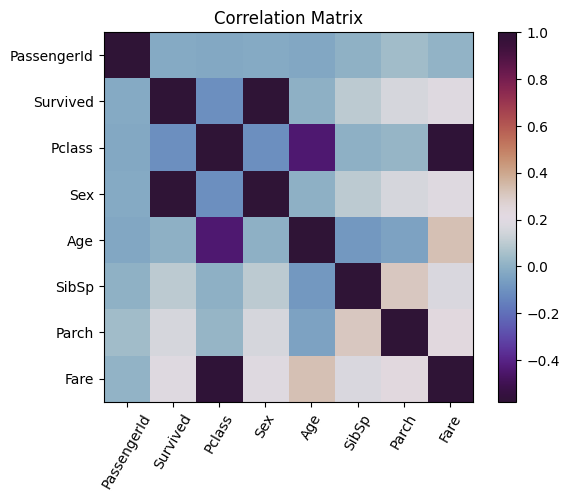

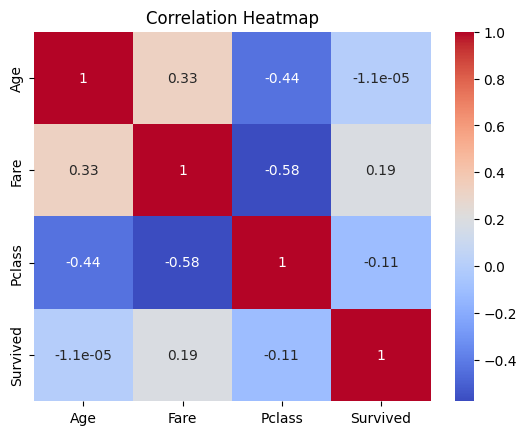

In [20]:
# -------------------- Correlation --------------------

# Correlation Matrix
corr = df.corr(numeric_only=True)
plt.imshow(corr, cmap='twilight_shifted')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=60)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

# Correlation Heatmap
corr = df[['Age', 'Fare', 'Pclass', 'Survived']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

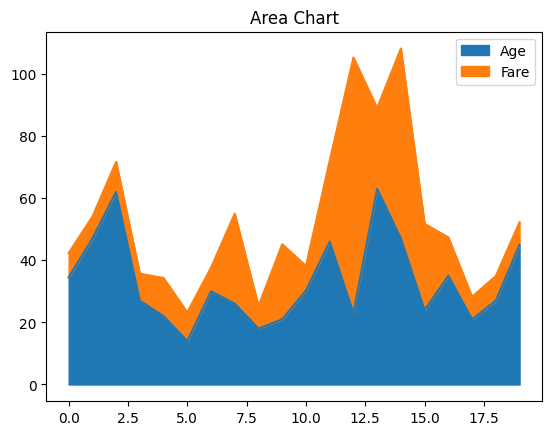

In [21]:
# -------------------- Area Chart --------------------

df[['Age', 'Fare']].fillna(0).head(20).plot.area()
plt.title("Area Chart")
plt.show()

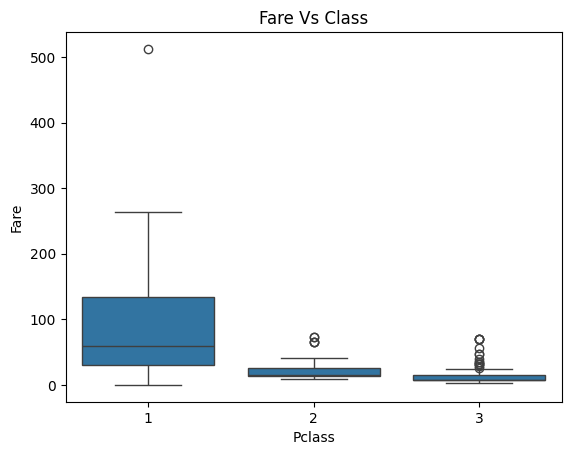

In [22]:
# Boxplot (Pclass vs Fare)
sns.boxplot(x='Pclass', y='Fare', data=df)
plt.title("Fare Vs Class")
plt.show()

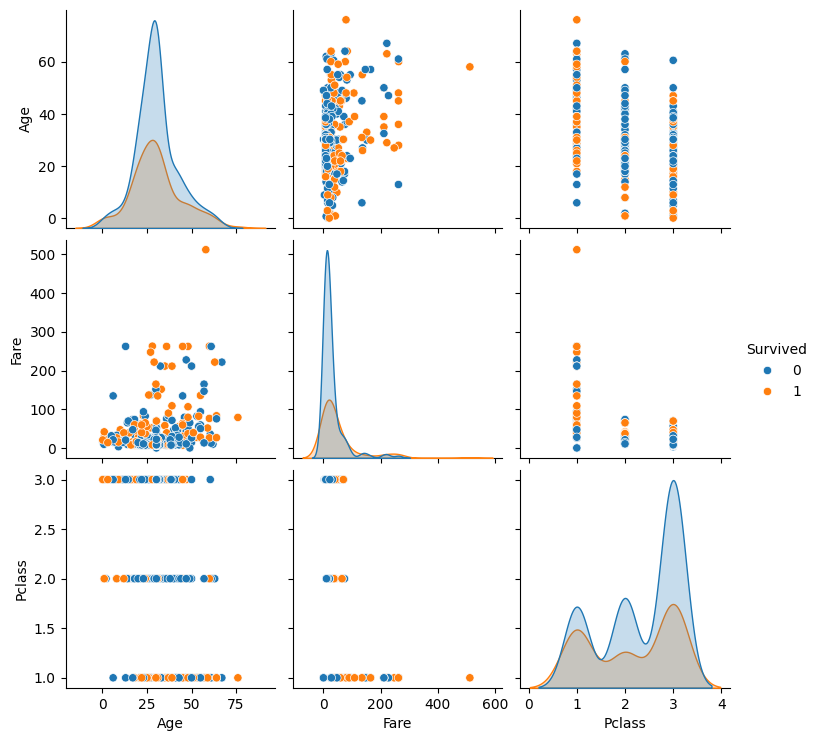

In [23]:
# -------------------- Multivariate Analysis --------------------

# Pairplot
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']], hue='Survived')
plt.show()